# ROBOT SCARA RRP

Un robot SCARA es un robot industrial diseñado para operaciones rápidas y precisas de ensamblaje y manipulación. Su estructura ofrece flexibilidad en el plano horizontal y rigidez vertical, lo que lo convierte en una herramienta ideal para tareas repetitivas en líneas de producción. Su nombre proviene de Selective Compliance Assembly Robot Arm, resaltando su capacidad de cumplir selectivamente en ciertos ejes para optimizar el montaje de componentes.

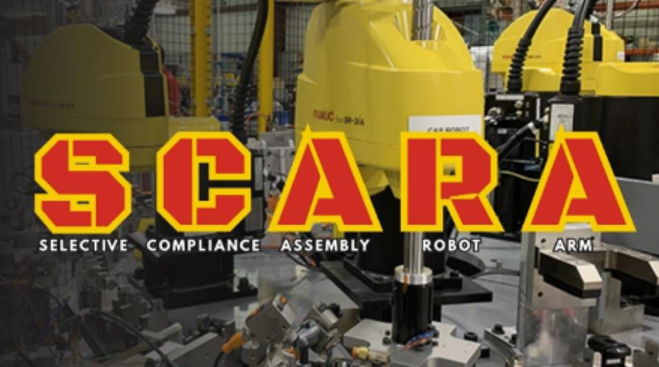

### Robot propuesto

A continuación se muestra el diseño del robot SCARA propuesto para este proyecto. Esta representación ilustra la estructura general del robot, incluyendo las articulaciones rotacionales (*q1* y *q2*) y el desplazamiento vertical (*d3*). El diseño permite visualizar la configuración mecánica y los elementos principales que conforman el sistema, sirviendo como referencia para comprender su funcionamiento y alcance durante las pruebas realizadas.

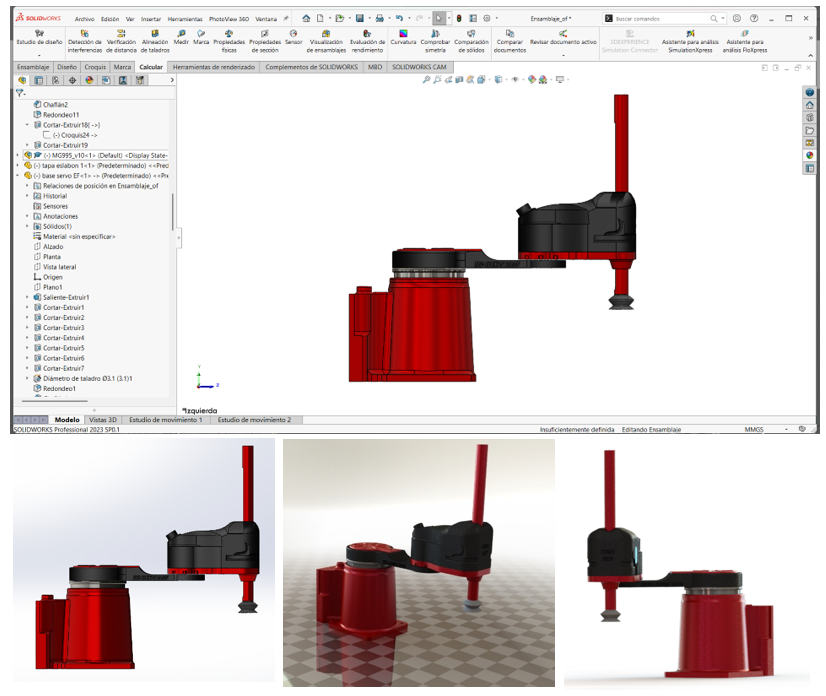

### Esquema del robot propuesto para parámetros Denavit - Hartenberg

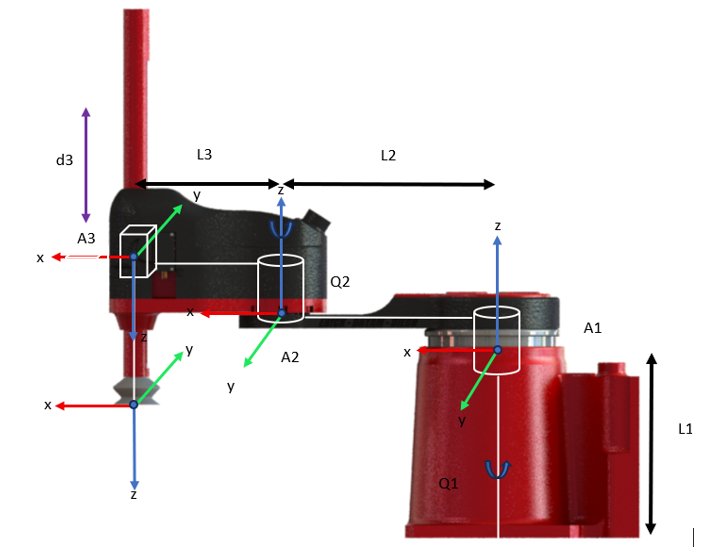

### Tabla de parámetros Denavit - Hatenberg del robot

| ESLABÓN | Θ | D | A | α | 
|--------|------|-------|--------|--------|
| 1 (Q1) | θ*   | 10.75 | 12.07 | 0°     | 
| 2 (Q2) | θ*   | 0     | 8.44  | 180°   | 
| 3 (Z)  | 0    | d*    | 0     | 0°     | 


## CODIGO DE CONTROL DEL ROBOT SCARA

La siguiente celda prepara el entorno del notebook para que pueda reconocer correctamente los archivos del proyecto SCARA.
Primero, identifica el directorio actual de trabajo y después agrega las rutas necesarias al sys.path, lo cual permite importar sin problemas módulos externos como app.py y scara_kinematics.py.
Además, se incluyen las carpetas templates y static, que contienen los archivos HTML utilizados por la interfaz web del sistema.
Esta configuración garantiza que todos los componentes del proyecto puedan ejecutarse y comunicarse adecuadamente dentro del Jupyter Notebook.

In [6]:
import os, sys

# --- 1. Establecer el directorio base ---
BASE_DIR = os.getcwd()
print("📁 Working directory:", BASE_DIR)

# --- 2. Agregar rutas al sys.path ---
sys.path.append(BASE_DIR)                          # raíz
sys.path.append(os.path.join(BASE_DIR))           # mismo nivel
sys.path.append(os.path.join(BASE_DIR, "static")) # carpeta static
sys.path.append(os.path.join(BASE_DIR, "templates")) # carpeta templates

print("🔍 Rutas añadidas al sys.path:")
for p in sys.path[-4:]:
    print("  ➤", p)


📁 Working directory: c:\Users\Bryam\Documents\ITSRLL 2025\Robotica Avanzada\ROBOT SCARA\ROBOT SCARA\ROBOT BRYAM SCARA\SIMULADOR\SCARA GEMINI
🔍 Rutas añadidas al sys.path:
  ➤ c:\Users\Bryam\Documents\ITSRLL 2025\Robotica Avanzada\ROBOT SCARA\ROBOT SCARA\ROBOT BRYAM SCARA\SIMULADOR\SCARA GEMINI
  ➤ c:\Users\Bryam\Documents\ITSRLL 2025\Robotica Avanzada\ROBOT SCARA\ROBOT SCARA\ROBOT BRYAM SCARA\SIMULADOR\SCARA GEMINI
  ➤ c:\Users\Bryam\Documents\ITSRLL 2025\Robotica Avanzada\ROBOT SCARA\ROBOT SCARA\ROBOT BRYAM SCARA\SIMULADOR\SCARA GEMINI\static
  ➤ c:\Users\Bryam\Documents\ITSRLL 2025\Robotica Avanzada\ROBOT SCARA\ROBOT SCARA\ROBOT BRYAM SCARA\SIMULADOR\SCARA GEMINI\templates


### Configuración del Servidor `app.py`

🦾 Servidor Flask + SocketIO para Control de Robot SCARA (Gemelo Digital + ESP32)

Este notebook utiliza el archivo `app.py`, el cual implementa un **servidor Flask con SocketIO** encargado de:

- Comunicar el **Teach Pendant**, la **simulación 3D** y el **gemelo digital**.
- Enviar comandos en tiempo real al **hardware físico (ESP32)** mediante UDP.
- Ejecutar **cinemática directa e inversa** usando `scara_kinematics.py`.
- Gestionar movimientos tanto en:
  - **JSI** – Joint Space Interpolation (espacio articular).
  - **LIC** – Linear Interpolation in Cartesian (trayectorias rectas en espacio cartesiano).
- Controlar funciones avanzadas:
  - Interpolación dinámica paso a paso.
  - Velocidad ajustable.
  - Rutinas guardadas (teach mode).
  - Paro de emergencia.
  - Sincronización gemelo digital ↔ robot físico.

Este servidor debe ser ejecutado junto con los archivos:

- `app.py` → Servidor Flask + SocketIO + UDP
- `scara_kinematics.py` → Modelo cinemático del robot
- `pendant.html`, `panel.html`, `scara_ajustador.html` → Interfaces web

Puedes usar este notebook para:
- Visualizar partes del código.
- Ejecutar pruebas aisladas.
- Cargar módulos.
- Comprobar funcionamiento del servidor SCARA.

> ⚠️ Nota: Para correr el servidor en una terminal externa debes usar:
> ```bash
> python app.py
> ```


In [ ]:
%%writefile app.py
# -*- coding: utf-8 SERVIDOR-*-

from flask import Flask, render_template
from flask_socketio import SocketIO, emit
import socket
from time import sleep 
from scara_kinematics import ScaraRobot 
import numpy as np 

app = Flask(__name__)
# Configuración de SocketIO para aceptar conexiones desde cualquier origen (CORS)
socketio = SocketIO(app, cors_allowed_origins="*")

# --- CONFIGURACIÓN DE RED ---
ESP32_IP = "192.168.0.11" # IP de tu ESP32
ESP32_PORT = 4210
# Se crea un socket UDP para enviar comandos rápidos a la ESP32
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM) 

# Instancia del modelo de cinemática
# NOTA: Se asume que 'scara_kinematics.py' está disponible y tiene la clase ScaraRobot
# con los métodos 'forward_kinematics' e 'inverse_kinematics'.
robot = ScaraRobot()
rutina_guardada = [] # Lista para guardar los puntos de la rutina

# --- VARIABLE GLOBAL DE VELOCIDAD Y MODO DE INTERPOLACIÓN ---
velocidad_actual = 50 
current_interpolation_mode = 'JSI' # Predeterminado a Articular

# --- FLAGS DE ESTADO DE CONTROL ---
is_routine_running = False
emergency_stop_active = False # Flag para el Paro de Emergencia

# --- Rutas de Archivos HTML (Renderizado) ---
@app.route('/pendant')
def pendant():
    """Sirve la interfaz del Teach Pendant."""
    # NOTA: Se asume que 'pendant.html' existe en la carpeta 'templates'
    return render_template('pendant.html')

@app.route('/panel')
def panel():
    """Sirve la interfaz de la simulación 3D."""
    # NOTA: Se asume que 'panel.html' existe en la carpeta 'templates'
    return render_template('panel.html')

@app.route('/scara_ajustador')
def scara_ajustador():
    """Ruta para renderizar la herramienta de ajuste visual SCARA (Kinematics)."""
    # NOTA: Se asume que 'scara_ajustador.html' existe en la carpeta 'templates'
    return render_template('scara_ajustador.html')

@app.route('/scara_manguera')
def scara_manguera():
    """Ruta para renderizar la herramienta de ajuste visual SCARA (Catenary)."""
    # NOTA: Se asume que 'scara_manguera.html' existe en la carpeta 'templates'
    return render_template('scara_manguera.html')

# --- Función de Comunicación con Hardware Físico ---
def enviar_a_esp32(q1, q2, z, grip):
    """Envía los ángulos y estado del grip al hardware a través de UDP."""
    # Formato de mensaje: "q1,q2,z,grip" ejemplo: "45.5,-10.2,0,1"
    mensaje = f"{q1},{q2},{z},{grip}"
    try:
        sock.sendto(mensaje.encode(), (ESP32_IP, ESP32_PORT))
    except:
        # Silenciamos el error para no llenar la consola si la ESP está apagada
        pass

# --- Función Helper: Interpolación en Espacio Articular (JSI - Joint Space Interpolation) ---
def _interpolate_and_move_joint(q1_start, q2_start, z_start, q1_end, q2_end, z_end, grip_state, movement_steps=100):
    """Mueve el robot de un estado articular a otro con interpolación lineal (JSI). Genera un arco en cartesiano."""
    global emergency_stop_active

    PASOS = movement_steps
    DELAY_BASE = 0.005 # AJUSTE: Reducido de 0.01 a 0.005s (Aumenta la frecuencia a 200Hz para mayor velocidad)

    tiempo_total_estimado = 0.0 # Acumulador de tiempo

    for paso in range(1, PASOS + 1):
        if emergency_stop_active: 
            return False, tiempo_total_estimado # Retornar tiempo aunque se interrumpa

        t = paso / PASOS 

        # Interpolación lineal de ángulos
        q1_temp = q1_start + (q1_end - q1_start) * t
        q2_temp = q2_start + (q2_end - q2_start) * t
        z_temp = z_start + (z_end - z_start) * t

        # Ejecutar el paso
        # Se llama a handle_manual para mover el robot y actualizar el gemelo digital
        handle_manual({'q1': q1_temp, 'q2': q2_temp, 'z': z_temp, 'grip': grip_state})

        # Gestión de Velocidad Dinámica
        factor = max(velocidad_actual, 1) / 100.0 
        tiempo_espera = DELAY_BASE / factor
        tiempo_total_estimado += tiempo_espera

        socketio.sleep(tiempo_espera) # Usamos socketio.sleep para no bloquear el hilo

    return True, tiempo_total_estimado # Movimiento completado

# --- NUEVA FUNCIÓN: Interpolación en Espacio Cartesiano (LIC - Linear Interpolation in Cartesian) ---
def _interpolate_and_move_linear(x_start, y_start, z_start, x_end, y_end, z_end, grip_state, movement_steps=100):
    """Mueve el robot con interpolación lineal en el espacio cartesiano (LIC). Genera una línea recta."""
    global emergency_stop_active

    PASOS = movement_steps
    DELAY_BASE = 0.005 # AJUSTE: Reducido de 0.01 a 0.005s (Aumenta la frecuencia a 200Hz para mayor velocidad)

    tiempo_total_estimado = 0.0 # Acumulador de tiempo

    for paso in range(1, PASOS + 1):
        if emergency_stop_active: 
            return False, tiempo_total_estimado # Movimiento interrumpido

        t = paso / PASOS # Factor de progreso (0.0 a 1.0)

        # Interpolación lineal de coordenadas Cartesianas (LIC)
        x_temp = x_start + (x_end - x_start) * t
        y_temp = y_start + (y_end - y_start) * t
        z_temp_world = z_start + (z_end - z_start) * t

        # 1. Calcular Cinemática Inversa en cada paso para mantener la línea recta
        ik_result = robot.inverse_kinematics(x_temp, y_temp, z_temp_world)

        if ik_result is None:
            print(f"ERROR LIC: Paso {paso} fuera de alcance. Pos: ({x_temp:.2f}, {y_temp:.2f}, {z_temp_world:.2f})")
            # Enviamos la notificación de error si un punto intermedio falla
            socketio.emit('notificacion', {'msg': 'ERROR: Trayectoria lineal pasó por fuera de alcance intermedio.'})
            return False, tiempo_total_estimado # Fallo en la interpolación lineal

        q1_temp, q2_temp, z_despl_temp = ik_result # z_despl_temp es el desplazamiento del pistón

        # 2. Ejecutar el paso
        # Se llama a handle_manual para mover el robot y actualizar el gemelo digital
        handle_manual({'q1': q1_temp, 'q2': q2_temp, 'z': z_despl_temp, 'grip': grip_state})

        # Gestión de Velocidad Dinámica
        factor = max(velocidad_actual, 1) / 100.0 
        tiempo_espera = DELAY_BASE / factor
        tiempo_total_estimado += tiempo_espera

        socketio.sleep(tiempo_espera) # Usamos socketio.sleep para no bloquear el hilo

    return True, tiempo_total_estimado # Movimiento completado


# --- Eventos de SocketIO (Recepción de Comandos del Pendant/Panel) ---

@socketio.on('cambiar_velocidad')
def handle_speed_change(data):
    """Actualiza la velocidad global de ejecución de la rutina."""
    global velocidad_actual
    velocidad_actual = int(data['velocidad'])

@socketio.on('set_interpolation_mode')
def set_interpolation_mode(data):
    """Actualiza el modo de interpolación global (JSI o LIC)."""
    global current_interpolation_mode
    mode = data.get('mode', 'JSI')
    if mode in ['JSI', 'LIC']:
        current_interpolation_mode = mode
        print(f"Modo de interpolación global cambiado a: {current_interpolation_mode}")
    else:
        print(f"Advertencia: Modo de interpolación '{mode}' no válido.")

@socketio.on('request_status')
def send_status():
    """Envía la IP del servidor a los clientes (para que el Pendant muestre 'SVR IP')."""
    hostname = socket.gethostname()
    try:
        ip_address = socket.gethostbyname(hostname)
    except socket.gaierror:
        ip_address = "IP No Disponible"

    emit('server_status', {'ip': ip_address})

@socketio.on('comando_manual')
def handle_manual(data):
    """
    Recibe un comando manual, calcula cinemática, envía al hardware
    y actualiza a todos los clientes (Gemelo Digital).
    """
    global emergency_stop_active

    # Asegurarse de que los datos de entrada son float/int
    q1 = float(data['q1'])
    q2 = float(data['q2'])
    z = float(data['z'])
    grip = int(data['grip'])

    # Actualizar la posición interna del robot y calcular coords
    robot.q1 = q1
    robot.q2 = q2
    robot.z = z
    robot.grip = grip

    # 1. Calcular cinemática para el Gemelo Digital
    coords = robot.forward_kinematics(q1, q2, z)

    # 2. Enviar a la ESP32 (Físico), solo si E-STOP no está activo
    if not emergency_stop_active:
        enviar_a_esp32(q1, q2, z, grip)

    # 3. Actualizar Gemelo Digital (PC)
    socketio.emit('actualizar_gemelo', {
        'angulos': data, 
        'coords': coords
    })

@socketio.on('comando_cartesiano')
def handle_cartesian_command(data):
    """
    Recibe una coordenada cartesiana (X, Y, Z) y el modo de interpolación.
    Realiza una comprobación de alcance del punto objetivo ANTES de iniciar la interpolación.
    """
    global is_routine_running, emergency_stop_active

    if emergency_stop_active:
        socketio.emit('notificacion', {'msg': 'ERROR: E-STOP Activo. Rearme con RESET.'})
        return

    if is_routine_running:
        socketio.emit('notificacion', {'msg': 'ERROR: Otra rutina o comando en ejecución.'})
        return

    try:
        x_obj = float(data['x'])
        y_obj = float(data['y'])
        z_world_obj = float(data['z_world'])
        grip = int(data.get('grip', robot.grip))
        mode = data.get('mode', 'JSI')
    except (ValueError, TypeError):
        socketio.emit('notificacion', {'msg': 'ERROR: Coordenadas o modo inválidos.'})
        return

    # --- COMPROBACIÓN CRÍTICA DE ALCANCE DEL OBJETIVO ---
    ik_target_check = robot.inverse_kinematics(x_obj, y_obj, z_world_obj)

    if ik_target_check is None:
        # Notificar al cliente que el punto objetivo está fuera de los límites cinemáticos/articulares
        socketio.emit('notificacion', {'msg': 'ERROR: El punto objetivo (B) está fuera del alcance cinemático o de límites (Q1).'})
        return

    # El punto es alcanzable. Continuamos con la interpolación.
    q1_obj, q2_obj, z_despl_obj = ik_target_check # Usamos este IK calculado

    # --- 1. Determinar Posición Inicial (A) ---
    q1_start = robot.q1
    q2_start = robot.q2
    z_despl_start = robot.z

    # Calcular la posición cartesiana de inicio (necesaria para LIC)
    start_coords = robot.forward_kinematics(q1_start, q2_start, z_despl_start)
    x_start = start_coords['final']['x']
    y_start = start_coords['final']['y']
    z_world_start = start_coords['final']['z']

    success = False
    total_time = 0.0

    if mode == 'JSI':
        # --- MODO ARTICULAR (JSI - Arco Circular) ---
        is_routine_running = True

        success, total_time = _interpolate_and_move_joint(
            q1_start=q1_start, q2_start=q2_start, z_start=z_despl_start,
            q1_end=q1_obj, q2_end=q2_obj, z_end=z_despl_obj, # Usamos el IK ya verificado
            grip_state=grip, movement_steps=100
        )

    elif mode == 'LIC':
        # --- MODO LINEAL (LIC - Línea Recta) ---
        is_routine_running = True

        success, total_time = _interpolate_and_move_linear(
            x_start=x_start, y_start=y_start, z_start=z_world_start,
            x_end=x_obj, y_end=y_obj, z_end=z_world_obj,
            grip_state=grip, movement_steps=100
        )
    else:
        socketio.emit('notificacion', {'msg': f'ERROR: Modo de interpolación "{mode}" no soportado.'})
        is_routine_running = False
        return

    # --- 2. Finalización del Movimiento ---
    is_routine_running = False

    if success:
        # Asegurar que el estado final sea la posición objetivo (B)
        handle_manual({'q1': q1_obj, 'q2': q2_obj, 'z': z_despl_obj, 'grip': grip})
        # El mensaje indica que el tiempo no se mide con precisión en movimientos unitarios
        socketio.emit('notificacion', {'msg': f'Movimiento Cartesiano ({mode}) Finalizado (Tiempo no medido en movimientos unitarios)'})
        # Eliminada la emisión de 'move_kinetics' aquí, ya que solo debe medir rutinas.
    else:
        if emergency_stop_active:
            socketio.emit('notificacion', {'msg': '!!! COMANDO CARTESIANO INTERRUMPIDO (E-STOP) !!!'})


@socketio.on('guardar_punto')
def guardar_punto(data):
    """
    Guarda la posición actual MÁS el modo de interpolación global
    para definir el TIPO de movimiento hacia ese punto.
    """
    global current_interpolation_mode
    # Añadimos el modo actual al punto guardado
    data['mode'] = current_interpolation_mode
    rutina_guardada.append(data)
    print(f"Punto guardado. Total: {len(rutina_guardada)}. Modo: {current_interpolation_mode}")
    socketio.emit('notificacion', {'msg': f'Punto {len(rutina_guardada)} guardado (Modo: {current_interpolation_mode})'})

@socketio.on('ejecutar_rutina')
def ejecutar_rutina():
    """
    Ejecuta la rutina guardada, utilizando el modo de interpolación 
    específico almacenado con cada punto.
    """
    global is_routine_running, emergency_stop_active

    if not rutina_guardada:
        socketio.emit('notificacion', {'msg': 'Error: Rutina vacía'})
        return

    if emergency_stop_active:
        socketio.emit('notificacion', {'msg': 'ERROR: E-STOP Activo. Rearme con RESET.'})
        return

    if is_routine_running: 
        socketio.emit('notificacion', {'msg': 'ERROR: Rutina ya en ejecución.'})
        return

    print("Iniciando Rutina Dinámica...")
    is_routine_running = True

    # Posiciones de inicio del movimiento (desde el estado actual del robot)
    q1_actual = robot.q1
    q2_actual = robot.q2
    z_actual = robot.z

    # Calcular la posición cartesiana de inicio (necesaria para LIC)
    start_coords = robot.forward_kinematics(q1_actual, q2_actual, z_actual)
    x_actual = start_coords['final']['x']
    y_actual = start_coords['final']['y']
    z_world_actual = start_coords['final']['z']

    rutina_time_total = 0.0 # Acumulador de tiempo para toda la rutina

    for i, punto_destino in enumerate(rutina_guardada):

        if emergency_stop_active:
            break

        print(f"Yendo al punto {i+1}...")

        try:
            q1_obj = float(punto_destino['q1'])
            q2_obj = float(punto_destino['q2'])
            z_obj = float(punto_destino['z'])
            grip = int(punto_destino['grip'])
            mode = punto_destino.get('mode', 'JSI') # Leer el modo guardado
        except (ValueError, KeyError):
            socketio.emit('notificacion', {'msg': f'ERROR: Punto {i+1} con datos inválidos.'})
            break

        # 1. Calcular Cinemática Directa del objetivo para obtener X, Y, Z_world si el modo es LIC.
        target_coords = robot.forward_kinematics(q1_obj, q2_obj, z_obj)
        x_obj = target_coords['final']['x']
        y_obj = target_coords['final']['y']
        z_world_obj = target_coords['final']['z']

        success = False
        segment_time = 0.01 # Inicialización

        if mode == 'LIC':
            # Ejecutar movimiento interpolado LINEAL (LIC)
            socketio.emit('notificacion', {'msg': f'Ejecutando P{i+1} (LIC)...'})
            success, segment_time = _interpolate_and_move_linear(
                x_start=x_actual, y_start=y_actual, z_start=z_world_actual,
                x_end=x_obj, y_end=y_obj, z_end=z_world_obj,
                grip_state=grip, movement_steps=100
            )
        else: # mode == 'JSI' (o cualquier otro por defecto)
            # Ejecutar movimiento interpolado ARTICULAR (JSI)
            socketio.emit('notificacion', {'msg': f'Ejecutando P{i+1} (JSI)...'})
            success, segment_time = _interpolate_and_move_joint(
                q1_start=q1_actual, q2_start=q2_actual, z_start=z_actual,
                q1_end=q1_obj, q2_end=q2_obj, z_end=z_obj,
                grip_state=grip, movement_steps=100
            )

        rutina_time_total += segment_time

        if not success:
            break

        # Actualizamos la posición de inicio para el siguiente tramo (siempre la posición objetivo)
        q1_actual = q1_obj
        q2_actual = q2_obj
        z_actual = z_obj
        x_actual = x_obj
        y_actual = y_obj
        z_world_actual = z_world_obj

        # Aplicamos la posición final (asegurar el estado exacto del punto)
        handle_manual({'q1': q1_actual, 'q2': q2_actual, 'z': z_actual, 'grip': grip})

        # *** NUEVO: Emitir el tiempo acumulado en tiempo real después de cada segmento ***
        socketio.emit('move_kinetics', {'time_ms': rutina_time_total * 1000})

        # COMENTADO/ELIMINADO: Pausa entre movimientos. 
        # La pausa forzada escalada inversamente con la velocidad (0.5s / factor de velocidad) 
        # causaba la lentitud percibida en la rutina, ya que se añadía tras cada punto.
        # factor = max(velocidad_actual, 1) / 100.0
        # pause_time = 0.5 / factor
        # rutina_time_total += pause_time 
        # socketio.sleep(pause_time)


    is_routine_running = False

    if emergency_stop_active:
        socketio.emit('notificacion', {'msg': '!!! RUTINA INTERRUMPIDA (E-STOP) !!!'})
    else:
        socketio.emit('notificacion', {'msg': 'Rutina Finalizada'})
        # La emisión final ya se realiza dentro del bucle, por lo que esta línea no es necesaria.


@socketio.on('emergency_stop')
def handle_emergency_stop():
    """Activa el flag de paro de emergencia y notifica a todos."""
    global emergency_stop_active
    emergency_stop_active = True
    # Enviar un comando de "parar" al hardware (ej. 0,0,0,0)
    enviar_a_esp32(0, 0, 0, 0) 
    print("!!! PARO DE EMERGENCIA ACTIVADO POR EL PENDANT !!!")
    socketio.emit('notificacion', {'msg': '!!! PARO DE EMERGENCIA !!!'})

@socketio.on('reset_routine')
def reset_routine():
    """Borra todos los puntos guardados en la rutina y desarma el E-STOP."""
    global rutina_guardada, emergency_stop_active
    puntos_borrados = len(rutina_guardada)
    rutina_guardada = []

    if emergency_stop_active:
        emergency_stop_active = False
    print("E-STOP desarmado con RESET.")
    socketio.emit('notificacion', {'msg': 'Paro de Emergencia Desarmado.'}) 

    print(f"Rutina de puntos borrada. Se eliminaron {puntos_borrados} puntos.")
    socketio.emit('notificacion', {'msg': f'Rutina Borrada. Puntos: {len(rutina_guardada)}'})


if __name__ == '__main__':
    print("Iniciando Servidor Flask/SocketIO en http://0.0.0.0:800")
    # Nota: allow_unsafe_werkzeug=True se añade por si se utiliza en un entorno específico
    socketio.run(app, host='0.0.0.0', port=800, debug=True, allow_unsafe_werkzeug=True)

Overwriting app.py


### 📌 Módulo `scara_kinematics.py` – Cinemática Directa e Inversa para Robot SCARA

Este módulo implementa la lógica completa de **cinemática directa** y **cinemática inversa** para un robot **SCARA** con:
- 2 articulaciones rotacionales (**Q1**, **Q2**)
- 1 articulación prismática (**Z**)
- Modelo geométrico basado en medidas CAD reales.

## 🔧 Características principales
- Define constantes geométricas del robot: longitudes de eslabones y offset del eje Z.
- Aplica límites físicos para los ángulos de Q1 y Q2.
- Incluye tolerancias para evitar errores por coma flotante.
- Permite obtener:
  - Coordenadas del efector final (**X, Y, Z**) a partir de ángulos (FK).
  - Ángulos requeridos (**Q1, Q2**) y desplazamiento en Z para alcanzar un punto (IK).
- Verifica que las posiciones estén dentro del rango mecánico del robot.

## 🧠 Clase `ScaraRobot`
### Métodos principales:

### `forward_kinematics(q1_deg, q2_deg, q3_val)`
Calcula la posición cartesiana final del efector usando los ángulos de articulación.

**Retorna:**
- Posición del codo (intermedio)
- Posición final (X, Y, Z)

---

### `inverse_kinematics(x, y, z_target)`
Calcula los ángulos necesarios para que el robot alcance un punto cartesiano.

**Incluye:**
- Validación de límites del eje Z  
- Validación de alcance físico  
- Restricciones angulares para Q1 y Q2  

**Retorna:**
- `(q1_deg, q2_deg, d3_cm)` si la posición es alcanzable  
- `None` si está fuera de límites

---

Este módulo sirve como núcleo matemático del robot SCARA y es utilizado por las interfaces de control, simulación y servidores en tiempo real.

In [ ]:
%%writefile scara_kinematics.py
# scara_kinematics.py
import numpy as np
from math import radians, degrees, cos, sin, sqrt, acos, atan2

# --- CONSTANTES CINEMÁTICAS (Medidas CAD Definitivas) ---
L1 = 12.07163    # Longitud del primer brazo (Hombro a Codo)
L2 = 8.443      # Longitud del segundo brazo (Codo a Muñeca/Efector Final)
D1_OFFSET = 10.75 # Altura inicial del efector final desde el suelo [cm] (Z en posición de reposo/superior)
Z_TRAVEL = 4.8  # Recorrido total del eje Z [cm] (desde la posición superior hasta la inferior)

# --- LÍMITES DE ARTICULACIONES ---
# Q1 (Base): Restringido al semicírculo frontal (e.g., -90 a +90 grados)
Q1_MIN_DEG = -90.0
Q1_MAX_DEG = 90.0
# Q2 (Codo): Restricción de rango ajustada a 90 grados según requerimiento.
Q2_MIN_DEG = -92.0
Q2_MAX_DEG = 92.0 

# TOLERANCIA: Un pequeño valor para manejar errores de coma flotante
EPSILON = 1e-6 

class ScaraRobot:
    """
    Implementa las transformaciones de cinemática directa e inversa
    para un robot SCARA de 2 grados de libertad rotacionales (Q1, Q2)
    y 1 grado de libertad prismático (Z).
    """
    def __init__(self):
        self.L1 = L1
        self.L2 = L2
        self.D1_OFFSET = D1_OFFSET
        self.Z_TRAVEL = Z_TRAVEL

        # Estado actual de las articulaciones (valores en grados para Q1, Q2 y cm para Z)
        self.q1 = 0.0
        self.q2 = 0.0
        self.z = 0.0
        self.grip = 0 # Estado del gripper (0: Abierto, 1: Cerrado)

    def forward_kinematics(self, q1_deg, q2_deg, q3_val):
        """
        Calcula las coordenadas finales (X, Y, Z) a partir de los ángulos de las articulaciones (Q1, Q2, Z).
        INPUT: Angles Q1 [deg], Q2 [deg], Z [cm, displacement of the piston]
        OUTPUT: Dictionary with final X, Y, Z coordinates.
        """
        self.q1 = q1_deg
        self.q2 = q2_deg
        self.z = q3_val

        q1 = radians(q1_deg)
        q2 = radians(q2_deg)

        # Direct Kinematics (SCARA 2D Formula)
        x_final = self.L1 * cos(q1) + self.L2 * cos(q1 + q2)
        y_final = self.L1 * sin(q1) + self.L2 * sin(q1 + q2)

        # Final Z (Height of the gripper above the floor)
        z_final = self.D1_OFFSET - q3_val

        return {
            "codo": {"x": self.L1 * cos(q1), "y": self.L1 * sin(q1)},
            "final": {"x": x_final, "y": y_final, "z": z_final}
        }

    def inverse_kinematics(self, x, y, z_target):
        """
        Calculates the necessary angles (Q1, Q2, d3) to reach a Cartesian position (X, Y, Z).
        Applies reach constraints and joint limits (Q1, Q2, Z).
        INPUT: Coordinates X, Y [cm] (in the working plane), Z_target [cm, desired height)
        OUTPUT: Tuple (q1_deg, q2_deg, d3_cm) or None if out of reach/limits.
        """

        # 1. Z Axis
        d3_cm = self.D1_OFFSET - z_target 

        # Z limit validation
        if not (-EPSILON <= d3_cm <= self.Z_TRAVEL + EPSILON):
            return None # Out of Z limit

        # 2. XY Axis
        R_sq = x**2 + y**2 
        R = sqrt(R_sq)

        # Physical reach criterion
        max_reach = self.L1 + self.L2
        min_reach = abs(self.L1 - self.L2)

        if R > max_reach + EPSILON or R < min_reach - EPSILON:
            return None # Out of reach

        # --- Inverse Kinematics Logic (Ley de los cosenos) ---

        # Angulo del codo (Q2)
        cos_q2 = (R_sq - self.L1**2 - self.L2**2) / (2 * self.L1 * self.L2)

        # Domain protection
        cos_q2 = max(min(cos_q2, 1.0 - EPSILON), -1.0 + EPSILON)

        q2_rad = acos(cos_q2) # "Right elbow" solution (Positive Q2)

        # Shoulder Angle (Q1)
        alfa = atan2(y, x)
        beta = atan2(self.L2 * sin(q2_rad), self.L1 + self.L2 * cos(q2_rad))

        q1_rad = alfa - beta

        q1_deg = degrees(q1_rad)
        q2_deg = degrees(q2_rad)

        # 3. Joint Limit Validation (Constraint Check)

        # Check Q1 limits (Frontal 180 degrees)
        if not (Q1_MIN_DEG - EPSILON <= q1_deg <= Q1_MAX_DEG + EPSILON):
             return None # Q1 out of allowed range

        # Check Q2 limits (e.g., 0 to 90 degrees)
        if not (Q2_MIN_DEG - EPSILON <= q2_deg <= Q2_MAX_DEG + EPSILON):
             return None # Q2 out of allowed range

        return q1_deg, q2_deg, d3_cm

Overwriting scara_kinematics.py


### 🖥️ Interfaz `panel.html` – Digital Twin del Robot SCARA



El archivo `panel.html` implementa la interfaz gráfica principal del **Digital Twin 3D** del robot SCARA.  
Desde esta página, el usuario puede visualizar el robot en un entorno tridimensional y controlar su movimiento mediante coordenadas cartesianas o interpolación articular.

---

## 🎨 Estructura general de la interfaz

La página se compone de dos áreas principales:

### **1. Panel izquierdo: Información del estado del robot**
Incluye elementos esenciales para monitorear el comportamiento del SCARA en tiempo real:

- **Parámetros Denavit–Hartenberg (D-H)**  
  Se muestran valores estáticos y dinámicos relacionados con la configuración del robot.

- **Estado articular actual**  
  - Q1 (Base)  
  - Q2 (Codo)  
  - d3 (Eje Z)

- **Posición cartesiana**  
  - Coordenadas X, Y y Z del efector final.

- **Matriz de transformación homogénea**  
  La matriz 4×4 se actualiza y muestra visualmente cada vez que el robot cambia de posición.

- **Tiempo de movimiento**  
  Se visualiza la duración del último desplazamiento del robot.

---

### **2. Panel derecho: Control cartesiano**
Permite enviar comandos directos al SCARA:

- **Posición inicial (A)**  
  Valores de referencia generados automáticamente.

- **Posición objetivo (B)**  
  Campos para ingresar coordenadas X, Y y Z que el robot deberá alcanzar.

- **Modos de interpolación**  
  - **LIC:** Interpolación lineal en espacio cartesiano  
  - **JSI:** Interpolación en espacio articular

- **Botón de ejecución**  
  Envía la orden de movimiento hacia el servidor.

---

## 🔌 Comunicación en tiempo real

El archivo se conecta al servidor mediante **Socket.IO**, permitiendo:

- Envío de trayectorias y objetivos cartesianos  
- Recepción del estado articular  
- Actualización continua de la matriz de transformación  
- Sincronización entre interfaz, simulación 3D y robot físico

---

## 🧩 Tecnologías utilizadas

`panel.html` integra varias herramientas:

- **Three.js** para la visualización 3D del robot  
- **Socket.IO** para comunicación bidireccional  
- **MathJax** para mostrar expresiones matemáticas  
- **CSS personalizado** para la presentación visual  
- **JavaScript** para cálculo local y actualización del panel

---

## 📄 Resumen

Este archivo representa la **interfaz de control cartesiano** del SCARA dentro del Digital Twin.  
Proporciona información completa del estado del robot, herramientas de control precisas y comunicación directa con el servidor y la simulación, facilitando un entorno robusto para monitoreo y operación del robot.



In [ ]:
%%writefile templates/panel.html
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>SCARA Digital Twin 3D (Final)</title>
    <!-- Incluir MathJax para referencia de la matriz -->
    <script id="MathJax-script" async src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

    <!-- Estilos personalizados para la interfaz -->
    <style>
        body { 
            margin: 0; 
            overflow: hidden; 
            background-color: #1a1a1a; 
            font-family: 'Inter', sans-serif; 
            color: white; 
            box-shadow: 0 10px 15px -3px rgba(0, 0, 0, 0.5), 0 4px 6px -2px rgba(0, 0, 0, 0.05);
        }
        #info {
            position: absolute;
            top: 20px;
            left: 20px;
            background: rgba(17, 24, 39, 0.9);
            padding: 10px; /* Reducido de 15px */
            border-radius: 12px;
            border: 1px solid #374151;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.4);
            pointer-events: none;
            width: 280px; /* Reducido de 300px */
            z-index: 10;
            max-height: 95vh;
            overflow-y: auto;
            font-size: 13px; /* Reducción de fuente base */
        }
        #control-panel {
            position: absolute;
            top: 20px;
            right: 20px;
            background: rgba(17, 24, 39, 0.9);
            padding: 15px; 
            border-radius: 12px;
            border: 1px solid #374151;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.4);
            width: 280px; 
            z-index: 10;
        }
        h1 { margin: 0 0 8px 0; font-size: 18px; color: #34d399; } /* Encabezado más pequeño */
        h2 { padding-bottom: 0px; margin-top: 10px; } /* Más compacto */
        p { margin: 3px 0; font-size: 13px; display: flex; justify-content: space-between; align-items: center; } /* Párrafos más compactos */
        span { font-weight: 700; color: #facc15; }
        hr { border-color: #4b5563; margin: 6px 0; } /* Margen de HR más pequeño */

        /* Estilo para inputs */
        .coord-input {
            background-color: #374151;
            border: 1px solid #4b5563;
            color: white;
            padding: 4px; /* Reducido */
            border-radius: 6px;
            width: 80px; /* Reducido */
            text-align: right;
            outline: none;
        }
        .coord-input:focus {
            border-color: #34d399;
            box-shadow: 0 0 0 2px rgba(52, 211, 153, 0.5);
        }
        .text-lg { font-size: 1rem; } 

        /* Estilos específicos para los radio buttons */
        .form-radio {
            appearance: none;
            width: 1em;
            height: 1em;
            border-radius: 50%;
            border: 2px solid #6b7280; 
            background-color: transparent;
            outline: none;
            cursor: pointer;
            transition: all 0.15s ease-in-out;
        }
        .form-radio:checked {
            border-color: currentColor;
            background-color: currentColor;
        }
        .text-cyan-500 { color: #06b6d4; }
        .text-yellow-500 { color: #f59e0b; }

        /* Estilos para la Matriz Dinámica */
        #matrix-display-container {
            border: 1px solid #4b5563;
            border-radius: 8px;
            padding: 3px; /* Reducido */
            background: #2b2b3b;
            box-shadow: inset 0 0 5px rgba(0,0,0,0.3);
        }
        #matrix-display-table {
            font-size: 10px; /* MUY COMPACTO */
            line-height: 1.1;
            color: #d1d5db; /* gray-300 */
        }
        #matrix-display-table td {
            padding: 2px; /* Reducido de 3px */
            border: none;
            min-width: 40px; /* Asegurar espacio mínimo para números */
        }
        #matrix-display-table tr:nth-child(4) td {
            color: #6b7280; /* gray-500 para la fila 4 */
        }
        .rot-val { color: #60a5fa; font-weight: 700; } /* blue-400 */
        .pos-val { color: #facc15; font-weight: 700; } /* yellow-400 */
        .fixed-val { color: #9ca3af; } /* gray-400 */

        /* Estilos para tabla D-H re-añadida */
        .dh-table {
            font-size: 11px; /* Reducido */
        }
        .dh-variable {
            color: #facc15; 
            font-weight: 900;
        }
        .dh-table-fixed {
            color: #d1d5db;
        }
        .dh-table th, .dh-table td {
             padding: 1px 2px; /* Reducido aún más */
        }
    </style>

    <script src="https://cdn.tailwindcss.com"></script>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/socket.io/4.0.1/socket.io.js"></script>
    <script type="importmap">
        {
            "imports": {
                "three": "https://cdn.jsdelivr.net/npm/three@0.160.0/build/three.module.js",
                "three/addons/": "https://cdn.jsdelivr.net/npm/three@0.160.0/examples/jsm/"
            }
        }
    </script>
</head>
<body>

    <div id="info">
        <h1>SCARA DIGITAL TWIN</h1>

        <!-- INICIO: TABLA DE PARÁMETROS D-H (COMPACTADA) -->
        <h2 class="text-sm font-semibold text-pink-400 border-b border-gray-600 pb-1 mt-4">PARÁMETROS DENAVIT-HARTENBERG (D-H)</h2>
        <table class="w-full text-xs text-left text-gray-300 mt-2 rounded-lg overflow-hidden dh-table">
            <thead class="text-xs text-white uppercase bg-gray-700">
                <tr>
                    <th scope="col">Eslabón</th>
                    <th scope="col">θ</th>
                    <th scope="col">d</th>
                    <th scope="col">a</th>
                    <th scope="col">α</th>
                    <th scope="col">Actual</th> <!-- NUEVA COLUMNA -->
                </tr>
            </thead>
            <tbody>
                <tr class="bg-gray-800 border-b border-gray-700">
                    <th scope="row" class="font-medium text-white whitespace-nowrap">1 (Q1)</th>
                    <td class="dh-variable">θ*</td> <!-- Variable -->
                    <td class="dh-table-fixed">10.75</td>
                    <td class="dh-table-fixed">12.07</td>
                    <td class="dh-table-fixed">0°</td>
                    <td id="dh_q1_theta" class="dh-variable">0.00°</td> <!-- Dinámico -->
                </tr>
                <tr class="bg-gray-800 border-b border-gray-700">
                    <th scope="row" class="font-medium text-white whitespace-nowrap">2 (Q2)</th>
                    <td class="dh-variable">θ*</td> <!-- Variable -->
                    <td class="dh-table-fixed">0</td>
                    <td class="dh-table-fixed">8.44</td>
                    <td class="dh-table-fixed">180°</td>
                    <td id="dh_q2_theta" class="dh-variable">0.00°</td> <!-- Dinámico -->
                </tr>
                <tr class="bg-gray-800">
                    <th scope="row" class="font-medium text-white whitespace-nowrap">3 (Z)</th>
                    <td class="dh-table-fixed">0</td>
                    <td class="dh-variable">d*</td> <!-- Variable -->
                    <td class="dh-table-fixed">0</td>
                    <td class="dh-table-fixed">0°</td>
                    <td id="dh_z_d" class="dh-variable">0.00 cm</td> <!-- Dinámico -->
                </tr>
            </tbody>
        </table>
        <!-- FIN: TABLA DE PARÁMETROS D-H -->

        <hr>

        <!-- LECTURAS ARTICULARES Y CARTESIANAS (COMPACTADO) -->
        <h2 class="text-sm font-semibold text-gray-300 border-b border-gray-600 pb-1 mt-4">POSICIONAMIENTO ACTUAL</h2>
        <p>Base (Q1): <span id="textQ1">0.00</span>°</p>
        <p>Codo (Q2): <span id="textQ2">0.00</span>°</p>
        <p>Desplazamiento (d3): <span id="textZ">0.00</span> cm</p>
        <hr>
        <p>POS X: <span id="textX">0.00</span> cm</p>
        <p>POS Y: <span id="textY">0.00</span> cm</p>
        <p>POS Z (Mundo): <span id="textZ_world">0.00</span> cm</p>
        <hr>

        <!-- INICIO: MATRIZ DE TRANSFORMACIÓN HOMOGÉNEA (COMPACTADA) -->
        <h2 class="text-sm font-semibold text-cyan-400 border-b border-gray-600 pb-1 mt-4">MATRIZ DE TRANSFORMACIÓN $H_3^0$</h2>

        <!-- Contenedor para la matriz en formato de tabla (actualización numérica) -->
        <div id="matrix-display-container" class="mt-2 text-xs font-mono">
            <table id="matrix-display-table" class="w-full text-center border-collapse">
                <!-- Fila 1: Rxx, Rxy, Rxz, Px -->
                <tr>
                    <td id="r11" class="rot-val">1.0000</td>
                    <td id="r12" class="rot-val">0.0000</td>
                    <td id="r13" class="fixed-val">0</td>
                    <td id="px" class="pos-val">0.00</td>
                </tr>
                <!-- Fila 2: Ryx, Ryy, Ryz, Py -->
                <tr>
                    <td id="r21" class="rot-val">0.0000</td>
                    <td id="r22" class="rot-val">1.0000</td>
                    <td id="r23" class="fixed-val">0</td>
                    <td id="py" class="pos-val">0.00</td>
                </tr>
                <!-- Fila 3: Rzx, Rzy, Rzz, Pz -->
                <tr>
                    <td id="r31" class="fixed-val">0</td>
                    <td id="r32" class="fixed-val">0</td>
                    <td id="r33" class="fixed-val">1</td>
                    <td id="pz" class="pos-val">0.00</td>
                </tr>
                <!-- Fila 4: 0, 0, 0, 1 -->
                <tr>
                    <td class="fixed-val">0</td>
                    <td class="fixed-val">0</td>
                    <td class="fixed-val">0</td>
                    <td class="fixed-val">1</td>
                </tr>
            </table>
        </div>

        <!-- Referencia de la matriz teórica -->
        <p style="font-size: 11px; text-align: center; color: #bbb; margin-top: 10px;">
            $H_{3}^0$ es la matriz de transformación homogénea total (Efector Final respecto a Base).
        </p>
        <!-- FIN: MATRIZ DE TRANSFORMACIÓN HOMOGÉNEA -->

        <hr>

        <!-- INICIO: PARÁMETROS CINÉTICOS (SIMPLIFICADO) -->
        <h2 class="text-sm font-semibold text-orange-400 border-b border-gray-600 pb-1 mt-4">PARÁMETROS CINÉTICOS</h2>
        <p>Tiempo Último Mov.: <span id="textTime" class="!text-cyan-400">0.00s</span></p>
        <hr>
        <!-- FIN: PARÁMETROS CINÉTICOS -->

        <p>Estado: <span id="status">...</span></p>
    </div>

    <!-- Panel de Control Cartesiano -->
    <div id="control-panel">
        <h1 class="!text-yellow-400">CONTROL CARTESIANO (IK)</h1>

        <div class="space-y-3">

            <!-- BLOQUE: Posición Actual (A) - Referencia de inicio -->
            <h2 class="text-sm font-semibold text-gray-300 border-b border-gray-600 pb-1">POSICIÓN ACTUAL (A)</h2>
            <div class="flex justify-between items-center text-xs">
                <p class="font-normal text-gray-400">X Actual:</p>
                <span id="currentXA" class="!text-yellow-200">0.00 cm</span>
            </div>
            <div class="flex justify-between items-center text-xs">
                <p class="font-normal text-gray-400">Y Actual:</p>
                <span id="currentYA" class="!text-yellow-200">0.00 cm</span>
            </div>
            <div class="flex justify-between items-center text-xs">
                <p class="font-normal text-gray-400">Z Actual:</p>
                <span id="currentZA" class="!text-yellow-200">0.00 cm</span>
            </div>

            <hr class="!my-4">

            <!-- BLOQUE: Posición Objetivo (B) - Edición manual del destino -->
            <h2 class="text-sm font-semibold text-green-400 border-b border-gray-600 pb-1">POSICIÓN OBJETIVO (B)</h2>
            <div class="flex justify-between items-center text-sm">
                <label for="inputXB">Posición X (cm):</label>
                <input type="number" id="inputXB" class="coord-input" value="15.00" step="0.1">
            </div>
            <div class="flex justify-between items-center text-sm">
                <label for="inputYB">Posición Y (cm):</label>
                <input type="number" id="inputYB" class="coord-input" value="0.00" step="0.1">
            </div>
            <div class="flex justify-between items-center text-sm">
                <label for="inputZB">Posición Z (cm):</label>
                <input type="number" id="inputZB" class="coord-input" value="10.75" step="0.1">
            </div>

            <hr class="!my-4">

            <!-- Selector de Modo de Movimiento -->
            <h2 class="text-sm font-semibold text-cyan-400 border-b border-gray-600 pb-1">MODO DE INTERPOLACIÓN</h2>
            <div class="flex flex-col space-y-1 text-sm">
                <label class="flex items-center space-x-2">
                    <input type="radio" name="movementMode" value="LIC" onchange="sendInterpolationMode()" checked class="form-radio text-cyan-500">
                    <span class="text-white font-semibold">Lineal (Línea Recta)</span>
                </label>
                <label class="flex items-center space-x-2">
                    <input type="radio" name="movementMode" value="JSI" onchange="sendInterpolationMode()" class="form-radio text-yellow-500">
                    <span class="text-white font-semibold">Articular (Arco Circular)</span>
                </label>
            </div>

            <button id="move-ab-btn" 
                    class="w-full py-2 mt-4 text-lg font-bold text-gray-900 bg-green-400 rounded-lg shadow-md hover:bg-green-500 transition duration-150 ease-in-out disabled:opacity-50"
                    onclick="sendCartesianCommand()">
                MOVER A POSICIÓN B
            </button>

            <hr class="!my-4">

            <h2 class="text-sm font-semibold text-purple-400 border-b border-gray-600 pb-1">HERRAMIENTAS</h2>
            <button id="clear-trajectory-btn" 
                    class="w-full py-2 mt-2 text-lg font-bold text-gray-900 bg-purple-400 rounded-lg shadow-md hover:bg-purple-500 transition duration-150 ease-in-out"
                    onclick="clearTrajectory()">
                LIMPIAR TRAYECTORIA
            </button>

            <button id="reset-time-btn" 
                    class="w-full py-2 mt-2 text-lg font-bold text-white bg-red-600 rounded-lg shadow-md hover:bg-red-700 transition duration-150 ease-in-out"
                    onclick="resetKineticTime()">
                REINICIAR TIEMPO
            </button>

        </div>

        <p class="mt-4 text-xs text-center text-gray-400" id="notification-msg">
            Listo.
        </p>

    </div>


    <script type="module">
        import * as THREE from 'three';
        import { OrbitControls } from 'three/addons/controls/OrbitControls.js';
        import { STLLoader } from 'three/addons/loaders/STLLoader.js';

        // --- 1. ESCENA ---
        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0x1a1a1a);

        const camera = new THREE.PerspectiveCamera(45, window.innerWidth / window.innerHeight, 0.1, 1000);
        camera.position.set(60, 60, 80);
        camera.lookAt(0, 10, 0);

        const renderer = new THREE.WebGLRenderer({ antialias: true });
        renderer.setSize(window.innerWidth, window.innerHeight);
        renderer.shadowMap.enabled = true;
        document.body.appendChild(renderer.domElement);

        const controls = new OrbitControls(camera, renderer.domElement);
        controls.enableDamping = true;
        controls.target.set(0, 10, 0);

        // Luces
        const ambientLight = new THREE.AmbientLight(0xffffff, 0.8);
        scene.add(ambientLight);
        const dirLight = new THREE.DirectionalLight(0xffffff, 1.5);
        dirLight.position.set(50, 100, 50);
        dirLight.castShadow = true;
        scene.add(dirLight);

        // Ayudas visuales
        const gridHelper = new THREE.GridHelper(100, 20, 0x333333, 0x222222);
        scene.add(gridHelper);
        const axesHelper = new THREE.AxesHelper(10);
        scene.add(axesHelper);

        // --- 2. CINEMÁTICA Y PROPIEDADES ---
        const KIN_L1 = 12.07163;
        const KIN_L2 = 8.443; 
        const KIN_BASE_H = 10.75;

        // Propiedades Visuales (Dimensiones ajustadas para el modelo 3D)
        const VIS_ARM1_H = 2.5; 
        const VIS_ARM2_H = 15.0; 
        const KIN_Z_TRAVEL = 4.8; 

        // Materiales
        const matYellow = new THREE.MeshStandardMaterial({ color: 0xFDFDFD, roughness: 0.6, metalness: 0.1 }); 
        const matBlack = new THREE.MeshStandardMaterial({ color: 0xC00030, roughness: 0.8, metalness: 0.1 }); 
        const matTube = new THREE.MeshStandardMaterial({ color: 0x050505, roughness: 0.8 }); 
        const matRed = new THREE.MeshStandardMaterial({ color: 0xff0000, roughness: 0.5, metalness: 0.1 }); 
        const matGreen = new THREE.MeshStandardMaterial({ color: 0x00ff00, roughness: 0.5, metalness: 0.1 }); 

        // --- 3. GRUPOS BASE (Estructura cinemática) ---

        // BASE
        const baseGroup = new THREE.Group();
        baseGroup.position.set(-8.48272886, 0.00000000, 5.05518680); 
        scene.add(baseGroup);

        // BRAZO 1 (Pivot Q1)
        const pivotQ1 = new THREE.Group();
        pivotQ1.position.y = KIN_BASE_H; 
        scene.add(pivotQ1);

        // BRAZO 2 (Pivot Q2)
        const pivotQ2 = new THREE.Group();
        pivotQ2.position.x = KIN_L1; 
        pivotQ1.add(pivotQ2);

        // PISTÓN / Z (Eje Z)
        const zPistonGroup = new THREE.Group();
        const z_retracted_y = (VIS_ARM2_H / 2) - (VIS_ARM1_H / 2); 
        zPistonGroup.position.x = KIN_L2; 
        zPistonGroup.position.y = z_retracted_y;
        pivotQ2.add(zPistonGroup);

        // GRIPPER (Grupo que se moverá con el pistón Z)
        const zRodVisualLength = KIN_Z_TRAVEL + (VIS_ARM2_H / 2); 
        const gripperGroup = new THREE.Group();
        gripperGroup.position.y = -zRodVisualLength;
        zPistonGroup.add(gripperGroup);

        // Punto de referencia para la trayectoria
        const trajectoryPoint = new THREE.Object3D();
        trajectoryPoint.position.set(0, 1.8, 0); 
        gripperGroup.add(trajectoryPoint);

        // FUELLE DE CABLES (Catenaria helpers - Anchors)
        const p1_base_anchor = new THREE.Object3D();
        p1_base_anchor.position.set(1.69778142, 6.54080060, -5.13516792); 
        p1_base_anchor.rotation.set(-3.10572151, 0.00000000, 0.00000000); 
        baseGroup.add(p1_base_anchor);

        const p3_head_anchor = new THREE.Object3D();
        p3_head_anchor.position.set(-0.02037288, 5.45878439, -0.38069293); 
        p3_head_anchor.rotation.set(-3.03399530, -0.02797794, -0.66214081); 
        pivotQ2.add(p3_head_anchor);

        // Curva inicial de la catenaria
        const tubePathInitial = new THREE.CatmullRomCurve3([
            new THREE.Vector3(0, KIN_BASE_H, 0), new THREE.Vector3(1, KIN_BASE_H + 5, 1), 
            new THREE.Vector3(10, KIN_BASE_H + 5, 0), new THREE.Vector3(KIN_L1, KIN_BASE_H, 0)
        ]);
        let tubeMesh = new THREE.Mesh(new THREE.TubeGeometry(tubePathInitial, 20, 0.7, 8, false), matTube);
        scene.add(tubeMesh);


        // --- 4. STL LOADER: Cargamos los modelos STL ---
        const loader = new STLLoader();

        function makeMeshFromSTL(geometry, material) {
            geometry.computeVertexNormals();
            const mesh = new THREE.Mesh(geometry, material);
            mesh.castShadow = true;
            mesh.receiveShadow = true;
            return mesh;
        }

        const basePath = '/static/models/'; 

        // 1) Base
        loader.load(encodeURI(basePath + 'BASE_BRAZO_OFICIAL.STL'), geometry => {
            const mesh = makeMeshFromSTL(geometry, matBlack);
            mesh.position.set(0.0000, 0.0000, 0.0000); 
            mesh.rotation.set(0.0000, 1.57079633, 0.0000); 
            mesh.scale.set(0.1000, 0.1000, 0.1000); 
            baseGroup.add(mesh);
        });

        // 2) Eslabon 1
        loader.load(encodeURI(basePath + 'ESLABON_UNO_OFICIAL_SCARA.STL'), geometry => {
            const mesh = makeMeshFromSTL(geometry, matYellow);
            mesh.position.set(-3.88355624, 0.06190888, 3.87835678); 
            mesh.rotation.set(-1.57884699, -0.00231147, -0.00194952); 
            mesh.scale.set(0.1000, 0.1000, 0.1000); 
            pivotQ1.add(mesh);
        });

        // 3) Eslabon 2
        loader.load(encodeURI(basePath + 'ESLABON_DOS_OFICIAL_SCARA.STL'), geometry => {
            const mesh = makeMeshFromSTL(geometry, matYellow);
            mesh.position.set(-12.23695849, -6.74478382, 2.05065598);
            mesh.rotation.set(0.02326533, 1.49006050, -0.02267558); 
            mesh.scale.set(0.1000, 0.1000, 0.1000); 
            pivotQ2.add(mesh);
        });

        let effectorInactiveMesh = null;
        let effectorActiveMesh = null;

        const effectorPos = new THREE.Vector3(2.98723537, -2.13966579, -15.51723759);
        const effectorRot = new THREE.Vector3(-0.00359393, -0.26862622, 0.00778434);
        const effectorSca = new THREE.Vector3(0.10000000, 0.10000000, 0.10000000);

        // Efector Inactivo (Rojo)
        loader.load(encodeURI(basePath + 'EFECTOR_FINAL_INACTIVO.STL'), geometry => {
            effectorInactiveMesh = makeMeshFromSTL(geometry, matRed); 
            effectorInactiveMesh.position.copy(effectorPos);
            effectorInactiveMesh.rotation.setFromVector3(effectorRot);
            effectorInactiveMesh.scale.copy(effectorSca);
            gripperGroup.add(effectorInactiveMesh);
        });

        // Efector Activo (Verde)
        loader.load(encodeURI(basePath + 'EFECTOR_FINAL_ACTIVO.STL'), geometry => {
            effectorActiveMesh = makeMeshFromSTL(geometry, matGreen); 
            effectorActiveMesh.visible = false; 
            effectorActiveMesh.position.copy(effectorPos);
            effectorActiveMesh.rotation.setFromVector3(effectorRot);
            effectorActiveMesh.scale.copy(effectorSca);
            gripperGroup.add(effectorActiveMesh);
        });

        // --- 5. TRAYECTORIA ---
        const trajectoryPoints = [];
        let trajectoryLine = null;
        const MAX_TRAJECTORY_POINTS = 500; // Límite de puntos en la trayectoria

        function updateTrajectory(currentEffectorPosition) {
            trajectoryPoints.push(currentEffectorPosition.clone());

            if (trajectoryPoints.length > MAX_TRAJECTORY_POINTS) {
                trajectoryPoints.shift(); // Eliminar el punto más antiguo
            }

            // Eliminar la línea anterior de la escena
            if (trajectoryLine) {
                scene.remove(trajectoryLine);
                trajectoryLine.geometry.dispose();
            }

            // Crear y añadir la nueva línea
            const geometry = new THREE.BufferGeometry().setFromPoints(trajectoryPoints);
            const material = new THREE.LineBasicMaterial({ color: 0xffff00 }); // Línea amarilla
            trajectoryLine = new THREE.Line(geometry, material);
            scene.add(trajectoryLine);
        }

        window.clearTrajectory = function() {
            if (trajectoryLine) {
                scene.remove(trajectoryLine);
                trajectoryLine.geometry.dispose();
                trajectoryLine = null;
            }
            trajectoryPoints.length = 0; // Vaciar el array de puntos
            document.getElementById('notification-msg').innerText = "Trayectoria limpiada.";
        }


        // --- 6. SOCKET.IO ---
        // Conexión por defecto al host que sirvió la página
        const socket = io(); 
        let currentGripState = 0; 

        socket.on('connect', () => { 
            const statusElement = document.getElementById('status');
            statusElement.innerText = "CONECTADO"; 
            statusElement.style.color = '#84cc16';
        });
        socket.on('disconnect', () => { 
            const statusElement = document.getElementById('status');
            statusElement.innerText = "DESCONECTADO"; 
            statusElement.style.color = '#ef4444';
        });

        // Manejar notificaciones del servidor
        socket.on('notificacion', (data) => {
            const notification = document.getElementById('notification-msg');
            const moveBtn = document.getElementById('move-ab-btn');

            notification.innerText = data.msg;
            if (data.msg.includes('ERROR') || data.msg.includes('!!!')) {
                notification.classList.remove('text-gray-400', 'text-green-400');
                notification.classList.add('text-red-500');
                // Habilitar botón si no es E-STOP (E-STOP lo debe deshabilitar hasta el RESET)
                if (!data.msg.includes('E-STOP')) {
                    moveBtn.disabled = false;
                }
            } else if (data.msg.includes('Finalizado') || data.msg.includes('Desarmado')) {
                notification.classList.remove('text-gray-400', 'text-red-500');
                notification.classList.add('text-green-400');
                moveBtn.disabled = false;
            } else {
                notification.classList.remove('text-red-500', 'text-green-400');
                notification.classList.add('text-gray-400');
            }

            // Gestión de estado de movimiento
            if (data.msg.includes('E-STOP Activo') || data.msg.includes('Ejecutando') || data.msg.includes('Movimiento Articular') || data.msg.includes('Movimiento Lineal')) {
                moveBtn.disabled = true;
            } else if (data.msg.includes('Finalizado') || data.msg.includes('ERROR') || data.msg.includes('Desarmado')) {
                 moveBtn.disabled = false;
            }
        });

        // MANEJO DE TIEMPO
        socket.on('move_kinetics', (data) => {
            const timeElement = document.getElementById('textTime');
            const totalSeconds = data.time_ms / 1000;
            timeElement.innerText = totalSeconds.toFixed(2) + 's';
        });


        socket.on('actualizar_gemelo', (data) => {
            if (!data || !data.angulos) return;

            currentGripState = data.angulos.grip;

            const q1_deg = parseFloat(data.angulos.q1);
            const q2_deg = parseFloat(data.angulos.q2);
            const z_despl = parseFloat(data.angulos.z); // Mantener sin toFixed para el cálculo de matriz

            // 1. Cálculos para la Matriz (Rotación)
            const degToRad = Math.PI / 180;
            const q_total_rad = (q1_deg + q2_deg) * degToRad;
            const cos_q_total = Math.cos(q_total_rad).toFixed(4);
            const sin_q_total = Math.sin(q_total_rad).toFixed(4);

            // 2. Actualizar interfaz de usuario (UI) General
            const z_despl_fixed = z_despl.toFixed(2);

            document.getElementById('textQ1').innerText = q1_deg.toFixed(2) + '°';
            document.getElementById('textQ2').innerText = q2_deg.toFixed(2) + '°';
            document.getElementById('textZ').innerText = z_despl_fixed + ' cm';

            // Re-añadir actualización de tabla D-H
            document.getElementById('dh_q1_theta').innerText = q1_deg.toFixed(2) + '°';
            document.getElementById('dh_q2_theta').innerText = q2_deg.toFixed(2) + '°';
            document.getElementById('dh_z_d').innerText = z_despl_fixed + ' cm';


            if (data.coords && data.coords.final) {
                const x = data.coords.final.x.toFixed(2);
                const y = data.coords.final.y.toFixed(2);
                const z = data.coords.final.z.toFixed(2);

                document.getElementById('textX').innerText = x;
                document.getElementById('textY').innerText = y;
                document.getElementById('textZ_world').innerText = z;

                // Actualizar panel de control de posición actual (A)
                document.getElementById('currentXA').innerText = x + ' cm';
                document.getElementById('currentYA').innerText = y + ' cm';
                document.getElementById('currentZA').innerText = z + ' cm';

                // --- 3. ACTUALIZAR MATRIZ HOMOGÉNEA (TABLA) ---

                // Rotación (R)
                document.getElementById('r11').innerText = cos_q_total; // cos(q1+q2)
                document.getElementById('r12').innerText = (-sin_q_total).toFixed(4); // -sin(q1+q2)
                document.getElementById('r21').innerText = sin_q_total; // sin(q1+q2)
                document.getElementById('r22').innerText = cos_q_total; // cos(q1+q2)

                // Posición (P)
                document.getElementById('px').innerText = x; // Px (X mundo)
                document.getElementById('py').innerText = y; // Py (Y mundo)
                document.getElementById('pz').innerText = z; // Pz (Z mundo)

                // Obtener la posición mundial del punto de trayectoria (gripper)
                const worldEffectorPosition = new THREE.Vector3();
                trajectoryPoint.getWorldPosition(worldEffectorPosition);
                updateTrajectory(worldEffectorPosition);
            }

            // 4. Actualizar Gemelo 3D
            pivotQ1.rotation.y = q1_deg * degToRad;
            pivotQ2.rotation.y = q2_deg * degToRad;
            // zPistonGroup se mueve en Y
            zPistonGroup.position.y = z_retracted_y - z_despl;

            // 5. GESTIÓN DE EFECTOR FINAL (VENTOSA)
            const effectorActive = data.angulos.grip === 1; 
            if (effectorInactiveMesh && effectorActiveMesh) {
                effectorInactiveMesh.visible = !effectorActive; 
                effectorActiveMesh.visible = effectorActive; 
            } 
        });

        // Función para enviar el modo de interpolación seleccionado al servidor
        window.sendInterpolationMode = function() {
            const mode = document.querySelector('input[name="movementMode"]:checked').value;
            socket.emit('set_interpolation_mode', { mode: mode });
            document.getElementById('notification-msg').innerText = `Modo establecido a: ${mode}`;
        }


        // --- FUNCIONES DE CONTROL CARTESIANO ---
        window.sendCartesianCommand = function() {
            const xB = parseFloat(document.getElementById('inputXB').value);
            const yB = parseFloat(document.getElementById('inputYB').value);
            const zB_world = parseFloat(document.getElementById('inputZB').value); 

            const mode = document.querySelector('input[name="movementMode"]:checked').value;

            const moveBtn = document.getElementById('move-ab-btn');

            if (isNaN(xB) || isNaN(yB) || isNaN(zB_world)) {
                document.getElementById('notification-msg').innerText = "ERROR: Ingrese valores numéricos válidos en Posición Objetivo (B).";
                return;
            }

            const targetX = xB;
            const targetY = yB;
            const targetZ = zB_world;

            let commandMessage = "";
            if (mode === 'LIC') {
                commandMessage = "Ejecutando Movimiento Lineal (Línea Recta) a Posición B...";
            } else {
                commandMessage = "Ejecutando Movimiento Articular (Arco Circular) a Posición B...";
            }

            moveBtn.disabled = true;
            document.getElementById('notification-msg').innerText = commandMessage;
            document.getElementById('textTime').innerText = '0.00s'; 

            // ENVIAR EL COMANDO AL SERVIDOR
            socket.emit('comando_cartesiano', {
                x: targetX,
                y: targetY,
                z_world: targetZ,
                grip: currentGripState,
                mode: mode 
            });
        }

        // NUEVA FUNCIÓN: Reinicia el tiempo cinético en el panel
        window.resetKineticTime = function() {
            document.getElementById('textTime').innerText = '0.00s';
            document.getElementById('notification-msg').innerText = 'Tiempo cinético reiniciado.';
        }

        // --- 7. ANIMACIÓN / RENDER LOOP (Lógica de Catenaria) ---

        // Función auxiliar para obtener la posición mundial de un ancla con un offset en su dirección local Y
        function getAnchorWorldPosition(anchorObject, offsetMultiplier) {
            const worldPos = new THREE.Vector3();
            anchorObject.getWorldPosition(worldPos);

            // Obtenemos la dirección Y local (que en el modelo STL apunta hacia abajo/frente al ancla)
            const worldDir = new THREE.Vector3(0, -1, 0); 
            worldDir.applyQuaternion(anchorObject.getWorldQuaternion(new THREE.Quaternion()));

            // Aplicamos el offset
            return worldPos.add(worldDir.multiplyScalar(offsetMultiplier));
        }

        function animate() {
            requestAnimationFrame(animate);
            controls.update();

            // --- Lógica de la Catenaria Animada (Interpolación de curvas Bezier) ---

            // Puntos de anclaje (P1 y P2)
            const P1_anchor = p1_base_anchor.getWorldPosition(new THREE.Vector3());
            const P2_anchor = p3_head_anchor.getWorldPosition(new THREE.Vector3());

            // Puntos de control offset (para darle "grosor" y curva inicial)
            const offset = 3; 
            const P1_world = getAnchorWorldPosition(p1_base_anchor, offset); 
            const P2_world = getAnchorWorldPosition(p3_head_anchor, offset); 

            // Direcciones normales (para los puntos de control intermedios)
            const P1_dir = P1_world.clone().sub(P1_anchor).normalize(); 
            const P2_dir = P2_world.clone().sub(P2_anchor).normalize(); 

            // Control Points C1 and C2 (extiende las direcciones de P1 y P2)
            const C1 = P1_anchor.clone().add(P1_dir.multiplyScalar(10)); 
            const C2 = P2_anchor.clone().add(P2_dir.multiplyScalar(10)); 

            // Punto medio (para la catenaria/caída visual)
            const midpoint = new THREE.Vector3().addVectors(C1, C2).multiplyScalar(0.5);
            // La caída es proporcional a la distancia entre anclas, más un mínimo.
            midpoint.y -= Math.max(0, P1_anchor.distanceTo(P2_anchor) / 10 + 2); 

            // Curva final (P1, C1, Midpoint, C2, P2)
            const newPath = new THREE.CatmullRomCurve3([P1_anchor, C1, midpoint, C2, P2_anchor]);

            // Recrear la geometría del tubo
            if (tubeMesh) {
                tubeMesh.geometry.dispose();
                tubeMesh.geometry = new THREE.TubeGeometry(newPath, 60, 0.7, 8, false); 
            }

            renderer.render(scene, camera);
        }

        window.onload = function () {
            animate();
            sendInterpolationMode(); // Establecer el modo predeterminado en el servidor
        };

        // Resize
        window.addEventListener('resize', onWindowResize, false);
        function onWindowResize() {
            camera.aspect = window.innerWidth / window.innerHeight;
            camera.updateProjectionMatrix();
            renderer.setSize(window.innerWidth, window.innerHeight);
        }
    </script>
</body>
</html>
      

Overwriting templates/panel.html


### 📟 Panel de Control – *Industrial Teach Pendant*

Este archivo define la interfaz gráfica del **teach pendant industrial** que controla el robot SCARA.  
La interfaz funciona desde cualquier navegador y se comunica en tiempo real con el servidor mediante **Socket.IO**.

### 🧩 Componentes principales del Panel

#### 🔴 1. Barra superior
- **E-STOP:** Botón de paro de emergencia que envía una señal inmediata al servidor.  
- **Power Switch:** Activa o desactiva la potencia de los motores del robot.

#### 🟩 2. Pantalla LCD
- Muestra:
  - Estado del WiFi  
  - Velocidad de Override (OVR)  
  - IP del servidor  
  - Valores actuales de los ejes `J1`, `J2` y `Z`  
  - Posición calculada en coordenadas cartesianas `X` y `Y`  
- Zona de mensajes del sistema: conexión, alertas o errores.

#### 🔢 3. Teclado de Control (Keypad)
Incluye botones distribuidos en una cuadrícula:
- **Control de velocidad:** Aumentar o disminuir override.
- **Jog de movimiento:**  
  - J1+/J1− para giro del primer eje  
  - J2+/J2− para el segundo eje  
  - Z+/Z− para el desplazamiento vertical  
- **Funciones:**  
  - HOME  
  - RESET  
  - Activación del gripper (GRIP)  
  - Guardar punto  
  - Ejecutar rutina automática

### ⚙️ Comunicación con el servidor
El panel:
- Envía comandos como *jog*, cambios de velocidad y movimientos manuales.  
- Recibe datos del gemelo digital para actualizar los valores mostrados en pantalla.  
- Maneja reconexiones y estados del sistema.

---

💡 *Este panel funciona como un control industrial real para mover un robot SCARA mediante un navegador web, con botones táctiles, velocidad variable y retroalimentación en vivo.*

In [ ]:
%%writefile templates/pendant.html
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=0.9, user-scalable=yes">
    <title>Industrial Teach Pendant</title>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/socket.io/4.0.1/socket.io.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Share+Tech+Mono&display=swap" rel="stylesheet">

    <style>
        /* Configuración Global para Scroll y Tactil */
        body {
            background-color: #121212;
            display: flex;
            justify-content: center;
            align-items: flex-start; /* Alineado arriba para permitir scroll */
            min-height: 100vh;
            margin: 0;
            font-family: sans-serif;

            /* Permitir Scroll vertical si la pantalla es chica */
            overflow-y: auto; 

            /* Evitar selección de texto */
            -webkit-user-select: none;
            user-select: none;
            -webkit-touch-callout: none;

            /* Espacio para que no pegue arriba y abajo */
            padding-top: 20px; 
            padding-bottom: 50px;
        }

        /* Carcasa del Control */
        .pendant-case {
            width: 90%; /* Ancho flexible */
            max-width: 380px; /* Tope máximo */

            /* Altura automática para ajustarse al contenido */
            height: auto; 
            min-height: 700px; 

            background-color: #3a3a3c;
            border-radius: 30px;
            box-shadow: inset 5px 5px 15px rgba(255,255,255,0.1), inset -5px -5px 15px rgba(0,0,0,0.5), 10px 10px 30px rgba(0,0,0,0.8);
            padding: 15px;
            display: flex;
            flex-direction: column;
            position: relative;
            border: 4px solid #2c2c2e;
        }

        /* Barra Superior */
        .top-bar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 10px;
        }

        .e-stop {
            width: 55px;
            height: 55px;
            background: radial-gradient(circle at 30% 30%, #ff4d4d, #cc0000);
            border-radius: 50%;
            border: 3px solid #800000;
            box-shadow: 0 5px 10px rgba(0,0,0,0.6);
            cursor: pointer;
            display: flex;
            align-items: center;
            justify-content: center;
            font-weight: bold;
            color: white;
            font-size: 9px;
            text-align: center;
        }
        .e-stop:active { transform: scale(0.95); box-shadow: 0 2px 5px rgba(0,0,0,0.6); }

        .power-switch {
            background: #222;
            color: #00ff00;
            padding: 8px 12px;
            border-radius: 5px;
            font-size: 11px;
            border: 1px solid #555;
            cursor: pointer;
        }
        .power-switch.off { color: #555; }

        /* --- PANTALLA LCD --- */
        .lcd-screen {
            background-color: #9ea792;
            color: #1a1a1a;
            font-family: 'Share Tech Mono', monospace;
            border: 6px solid #111;
            border-radius: 4px;
            padding: 8px;
            height: auto; 
            min-height: 200px;
            box-shadow: inset 2px 2px 10px rgba(0,0,0,0.4);
            margin-bottom: 15px;
            display: flex;
            flex-direction: column;
            justify-content: space-between;
        }

        .status-bar {
            font-size: 11px;
            border-bottom: 2px solid #1a1a1a;
            padding-bottom: 3px;
            display: flex;
            justify-content: space-between;
            font-weight: bold;
        }

        .data-lines { font-size: 15px; line-height: 1.3; margin-top: 5px; }
        .coord-label { font-weight: bold; margin-right: 8px; }

        .system-msg {
            background: #1a1a1a;
            color: #9ea792;
            padding: 3px;
            font-size: 10px;
            text-align: center;
            margin-top: 5px;
        }

        /* --- TECLADO --- */
        .keypad {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 8px;
            flex-grow: 1;
            background: #2c2c2e;
            padding: 10px;
            border-radius: 10px;
            border: 1px solid #555;
        }

        .key {
            background: linear-gradient(to bottom, #3b82f6, #1d4ed8);
            color: white;
            border: none;
            border-radius: 6px;
            font-weight: bold;
            font-size: 13px;
            cursor: pointer;
            box-shadow: 0 4px 0 #1e3a8a;
            height: 50px;
            display: flex;
            flex-direction: column;
            align-items: center;
            justify-content: center;
            touch-action: manipulation; 
            -webkit-tap-highlight-color: transparent;
        }

        .key:active { transform: translateY(4px); box-shadow: 0 0 0 #1e3a8a; }
        .key span { font-size: 8px; opacity: 0.8; margin-top: 1px; }

        .key.grey { background: linear-gradient(to bottom, #6b7280, #4b5563); box-shadow: 0 4px 0 #374151; }
        .key.dark-grey { background: linear-gradient(to bottom, #4b5563, #374151); box-shadow: 0 4px 0 #1f2937; font-size: 10px; }
        .key.yellow { background: linear-gradient(to bottom, #eab308, #ca8a04); box-shadow: 0 4px 0 #854d0e; color: black; }
        .key.green { background: linear-gradient(to bottom, #22c55e, #15803d); box-shadow: 0 4px 0 #14532d; }
        .key.red { background: linear-gradient(to bottom, #ef4444, #b91c1c); box-shadow: 0 4px 0 #7f1d1d; }

        .span-2 { grid-column: span 2; }

        .speed-display {
            background: #111;
            color: #00ffcc;
            font-family: 'Share Tech Mono', monospace;
            display: flex;
            align-items: center;
            justify-content: center;
            border-radius: 4px;
            border: 1px solid #555;
            font-size: 16px;
            box-shadow: inset 0 0 5px rgba(0,255,204,0.2);
        }

    </style>
</head>
<body>

    <div class="pendant-case">
        <div class="top-bar">
            <div class="e-stop" onclick="emergencia()">E-STOP</div>
            <div id="pwrBtn" class="power-switch" onclick="togglePower()">⚡ MOTOR OFF</div>
        </div>

        <div class="lcd-screen">
            <div class="status-bar">
                <span id="wifiStatus">WiFi: OK</span>
                <span id="speedOvr">OVR: 50%</span>
            </div>
            <div style="font-size: 10px; text-align: right; border-bottom: 1px solid #1a1a1a; margin-bottom: 5px;">
                <span id="ipDisplay">IP: ...</span>
            </div>

            <div class="data-lines">
                <div><span class="coord-label">J1:</span> <span id="lcd-q1">0.0</span>°</div>
                <div><span class="coord-label">J2:</span> <span id="lcd-q2">0.0</span>°</div>
                <div><span class="coord-label">Z :</span> <span id="lcd-z">0.0</span> cm</div>
                <hr style="border-color: #1a1a1a; opacity: 0.3; margin: 3px 0;">
                <div><span class="coord-label">X:</span> <span id="lcd-x">0.00</span></div>
                <div><span class="coord-label">Y:</span> <span id="lcd-y">0.00</span></div>
            </div>

            <div class="system-msg" id="sysMsg">SISTEMA LISTO</div>
        </div>

        <div class="keypad">
            <!-- CONTROL VELOCIDAD -->
            <button class="key dark-grey" onclick="changeSpeed(-5)">SPEED<br>▼</button>
            <div class="speed-display" id="keypadSpeed">50%</div>
            <button class="key dark-grey" onclick="changeSpeed(5)">SPEED<br>▲</button>

            <!-- EJE J1 -->
            <button class="key" 
                onmousedown="startJog('q1', -1, event)" onmouseup="stopJog(event)" onmouseleave="stopJog(event)"
                ontouchstart="startJog('q1', -1, event)" ontouchend="stopJog(event)">
                J1-<br><span>(Der)</span>
            </button>

            <button class="key grey" onclick="goHome()">HOME</button>

            <button class="key" 
                onmousedown="startJog('q1', 1, event)" onmouseup="stopJog(event)" onmouseleave="stopJog(event)"
                ontouchstart="startJog('q1', 1, event)" ontouchend="stopJog(event)">
                J1+<br><span>(Izq)</span>
            </button>

            <!-- EJE J2 -->
            <button class="key" 
                onmousedown="startJog('q2', -1, event)" onmouseup="stopJog(event)" onmouseleave="stopJog(event)"
                ontouchstart="startJog('q2', -1, event)" ontouchend="stopJog(event)">
                J2-<br><span>(In)</span>
            </button>

            <button class="key grey" onclick="resetToZero()">RESET</button>

            <button class="key" 
                onmousedown="startJog('q2', 1, event)" onmouseup="stopJog(event)" onmouseleave="stopJog(event)"
                ontouchstart="startJog('q2', 1, event)" ontouchend="stopJog(event)">
                J2+<br><span>(Out)</span>
            </button>

            <!-- EJE Z -->
            <button class="key" 
                onmousedown="startJog('z', 1, event)" onmouseup="stopJog(event)" onmouseleave="stopJog(event)"
                ontouchstart="startJog('z', 1, event)" ontouchend="stopJog(event)">
                Z-<br><span>(Down)</span>
            </button>

            <button class="key red" onclick="toggleGrip()">GRIP</button>

            <button class="key" 
                onmousedown="startJog('z', -1, event)" onmouseup="stopJog(event)" onmouseleave="stopJog(event)"
                ontouchstart="startJog('z', -1, event)" ontouchend="stopJog(event)">
                Z+<br><span>(Up)</span>
            </button>

            <!-- Acciones -->
            <button class="key yellow span-2" onclick="guardarPunto()">GUARDAR PUNTO</button>
            <button class="key green" onclick="ejecutarRutina()">RUN</button>
        </div>
    </div>

    <script>
        const socket = io();

        let currentQ1 = 0;
        let currentQ2 = 0;
        let currentZ = 0;
        let gripState = 0;
        let motorOn = false;
        let jogInterval = null;

        // Variables de velocidad
        let jogSpeedPercent = 50; 
        const MAX_STEP_DEG = 5.0; 
        const MAX_STEP_Z = 0.5;  

        let isJogging =  false;

        // Prevenir el menú contextual (click derecho/hold) en toda la app
        document.addEventListener('contextmenu', event => event.preventDefault());

        socket.on('connect', () => {
            document.getElementById('sysMsg').innerText = "CONECTADO AL SERVIDOR";
            document.getElementById('wifiStatus').innerText = "WiFi: OK";
            socket.emit('request_status');
        });

        socket.on('disconnect', () => {
            document.getElementById('sysMsg').innerText = "DESCONECTADO";
            document.getElementById('wifiStatus').innerText = "WiFi: --";
        });

        // --- NUEVO: MANEJO DE NOTIFICACIONES DEL SERVIDOR ---
        socket.on('notificacion', (data) => {
            const sysMsg = document.getElementById('sysMsg');
            sysMsg.innerText = data.msg;
            setTimeout(() => {
                // Restaurar mensaje de estado si no estamos en movimiento o emergencia
                if (!jogInterval && motorOn) {
                    sysMsg.innerText = "POTENCIA HABILITADA";
                } else if (!jogInterval && !motorOn) {
                    sysMsg.innerText = "SISTEMA LISTO";
                }
            }, 1000);
        });

        socket.on('actualizar_gemelo', (data) => {
            if(isJogging) return;

            document.getElementById('lcd-q1').innerText = parseFloat(data.angulos.q1).toFixed(1);
            document.getElementById('lcd-q2').innerText = parseFloat(data.angulos.q2).toFixed(1);
            document.getElementById('lcd-z').innerText = parseFloat(data.angulos.z).toFixed(1);
            if(data.coords) {
                document.getElementById('lcd-x').innerText = data.coords.final.x.toFixed(2);
                document.getElementById('lcd-y').innerText = data.coords.final.y.toFixed(2);
            }
            currentQ1 = parseFloat(data.angulos.q1);
            currentQ2 = parseFloat(data.angulos.q2);
            currentZ = parseFloat(data.angulos.z);
        });

        socket.on('server_status', (data) => {
            document.getElementById('ipDisplay').innerText = "SVR IP: " + data.ip;
        });

        // --- FUNCIÓN MODIFICADA: Enviar velocidad y actualizar UI ---
        function changeSpeed(delta) {
            jogSpeedPercent += delta;
            if(jogSpeedPercent > 100) jogSpeedPercent = 100;
            if(jogSpeedPercent < 5) jogSpeedPercent = 5;
            document.getElementById('speedOvr').innerText = "OVR: " + jogSpeedPercent + "%";
            document.getElementById('keypadSpeed').innerText = jogSpeedPercent + "%";

            // Avisar al servidor (para que afecte la rutina si está corriendo)
            socket.emit('cambiar_velocidad', { velocidad: jogSpeedPercent });
        }

        // --- LOGICA DE MOVIMIENTO CONTINUO ---
        function startJog(axis, direction, event) {
            // EVITAR el comportamiento por defecto del navegador
            if(event) {
                if(event.cancelable) event.preventDefault();
            }

            if (!motorOn) {
                document.getElementById('sysMsg').innerText = "ERROR: MOTOR OFF";
                return; 
            }

            // Si ya hay un intervalo corriendo, no creamos otro
            if (jogInterval) return;

            isJogging = true;

            const doStep = () => {
                let speedFactor = jogSpeedPercent / 100.0;
                let stepSize = (axis === 'z' ? MAX_STEP_Z : MAX_STEP_DEG);
                let finalStep = stepSize * speedFactor * direction;

                if (axis === 'q1') currentQ1 += finalStep;
                if (axis === 'q2') currentQ2 += finalStep;
                if (axis === 'z') currentZ += finalStep;

                // Límites
                if(currentQ1 > 90) currentQ1 = 90; if(currentQ1 < -90) currentQ1 = -90;
                if(currentQ2 > 90) currentQ2 = 90; if(currentQ2 < -90) currentQ2 = -90;
                if(currentZ > 4.8) currentZ = 4.8; if(currentZ < 0) currentZ = 0;

                sendMove();
            };

            doStep(); // Primer paso inmediato
            // Intervalo rápido (70ms) para sentirlo fluido
            jogInterval = setInterval(doStep, 90); 
        }

        function stopJog(event) {
            if(event && event.cancelable) event.preventDefault();
            clearInterval(jogInterval);
            jogInterval = null; 

            setTimeout(()=>{isJogging=false;},250);
        }

        function sendMove() {
            socket.emit('comando_manual', { 
                q1: currentQ1, 
                q2: currentQ2, 
                z: currentZ, 
                grip: gripState 
            });
        }

        function toggleGrip() {
            if (!motorOn) return;
            gripState = gripState === 0 ? 1 : 0;
            sendMove();
            document.getElementById('sysMsg').innerText = gripState ? "GRIP: CERRADO" : "GRIP: ABIERTO";
        }

        function togglePower() {
            motorOn = !motorOn;
            const btn = document.getElementById('pwrBtn');
            if (motorOn) {
                btn.classList.remove('off');
                btn.innerHTML = "⚡ MOTOR ON";
                btn.style.color = "#00ff00";
                document.getElementById('sysMsg').innerText = "POTENCIA HABILITADA";
            } else {
                btn.classList.add('off');
                btn.innerHTML = "⚡ MOTOR OFF";
                btn.style.color = "#555";
                document.getElementById('sysMsg').innerText = "POTENCIA CORTADA";
            }
        }

        // --- FUNCIÓN MODIFICADA: E-STOP con comunicación al servidor ---
        function emergencia() {
            motorOn = false;
            stopJog();
            togglePower();

            // 1. Enviar comando de Paro de Emergencia al servidor para detener la rutina
            socket.emit('emergency_stop');

            // 2. Mostrar alerta visual y mensaje
            document.getElementById('sysMsg').innerText = "!!! PARO DE EMERGENCIA !!!";
            document.getElementById('sysMsg').style.backgroundColor = "red";
            document.getElementById('sysMsg').style.color = "white";
            setTimeout(() => {
                // Resetear color después de 3s
                document.getElementById('sysMsg').style.backgroundColor = "#1a1a1a";
                document.getElementById('sysMsg').style.color = "#9ea792";
            }, 3000);
        }

        function guardarPunto() {
            socket.emit('guardar_punto', { q1: currentQ1, q2: currentQ2, z: currentZ, grip: gripState });
            // La notificación se gestiona ahora con socket.on('notificacion') desde el servidor
        }

        function ejecutarRutina() {
            if (!motorOn) { 
                document.getElementById('sysMsg').innerText = "ERROR: Motor OFF. Enciende los motores primero."; 
                return; 
            }
            socket.emit('ejecutar_rutina');
            document.getElementById('sysMsg').innerText = "EJECUTANDO...";
        }

        // --- FUNCIÓN DE RESET (Reinicia Posición y Borra Rutina) ---
        function resetToZero() {
            if (!motorOn) {
                 document.getElementById('sysMsg').innerText = "ERROR: MOTOR OFF";
                 return;
            }

            // 1. Resetear posición visual/robot
            currentQ1 = 0; 
            currentQ2 = 0; 
            currentZ = 0;

            // 2. Enviar posición de Home al robot/simulación
            sendMove();

            // 3. Enviar comando al servidor para borrar la rutina guardada y desarmar el E-STOP
            socket.emit('reset_routine');

            // 4. Mensaje local
            document.getElementById('sysMsg').innerText = "POSICIÓN RESETEADA. Borrando Rutina...";
        }

        // Go Home (mantener la función original para HOME)
        function goHome() {
             if (!motorOn) return;
             currentQ1 = 0; currentQ2 = 0; currentZ = 0;
             sendMove();
        }
    </script>
</body>
</html>

Overwriting templates/pendant.html


### (Código): ¡EJECUTAR SIMULACIÓN!

Esta es la celda final. Al darle *"Run"*, el notebook se bloqueará (aparecerá un asterisco `[ * ]`) y lanzará el servidor.



In [11]:
print("="*50)
print("INICIANDO SERVIDOR DEL GEMELO DIGITAL")
print("Abra en su navegador: http://localhost:800/panel")
print("Para detener el servidor, presione el botón de 'Stop' (Cuadrado) en el menú superior.")
print("="*50)

# Ejecutamos el script app.py que acabamos de crear
!python app.py


INICIANDO SERVIDOR DEL GEMELO DIGITAL
Abra en su navegador: http://localhost:800/panel
Para detener el servidor, presione el botón de 'Stop' (Cuadrado) en el menú superior.
^C
